In [1]:
import pandas as pd
df1=pd.read_csv("FILES/LOTR.csv")
df1

,FellowshipID,FirstName,Skills
0,1001,Frodo,Hiding
1,1002,Samwise,Gardening
2,1003,Gandalf,Spells
3,1004,Pippin,Fireworks


In [ ]:

df2=pd.read_csv("FILES/LOTR 2.csv")
df2

,FellowshipID,FirstName,Age
0,1001,Frodo,50
1,1002,Samwise,39
2,1006,Legolas,2931
3,1007,Elrond,6520
4,1008,Barromir,51


Merging the data frame

Using Merge method --> Easy & have some defaults

In [3]:
df1.merge(df2)

,FellowshipID,FirstName,Skills,Age
0,1001,Frodo,Hiding,50
1,1002,Samwise,Gardening,39


By default it is doing inner join --> Exact match in both data frame

In [4]:
df1.merge(df2,how='inner')

,FellowshipID,FirstName,Skills,Age
0,1001,Frodo,Hiding,50
1,1002,Samwise,Gardening,39


In [5]:
df1.merge(df2,how='inner',on='FellowshipID')

,FellowshipID,FirstName_x,Skills,FirstName_y,Age
0,1001,Frodo,Hiding,Frodo,50
1,1002,Samwise,Gardening,Samwise,39


In [6]:
df1.merge(df2,how="inner",on=["FellowshipID","FirstName"])

,FellowshipID,FirstName,Skills,Age
0,1001,Frodo,Hiding,50
1,1002,Samwise,Gardening,39


Outer join print all in both data frame (left and right)

So No full join worked here

In [7]:
df1.merge(df2,how='outer')

,FellowshipID,FirstName,Skills,Age
0,1001,Frodo,Hiding,50.0
1,1002,Samwise,Gardening,39.0
2,1003,Gandalf,Spells,NaN
3,1004,Pippin,Fireworks,NaN
4,1006,Legolas,NaN,2931.0
5,1007,Elrond,NaN,6520.0
6,1008,Barromir,NaN,51.0


Here we some NAN values --> If join could not find any matching or not found any values we can see that

In [8]:
df1.merge(df2,how='full')

ValueError: do not recognize join method full

Left join --> Exact match + Remaining data in left data frame 

So everything from the left dataframe will be there

In [9]:
df1.merge(df2,how="left")

,FellowshipID,FirstName,Skills,Age
0,1001,Frodo,Hiding,50.0
1,1002,Samwise,Gardening,39.0
2,1003,Gandalf,Spells,NaN
3,1004,Pippin,Fireworks,NaN


Right join --> Exact match + Remaining data in right data frame 

So everything from the right dataframe will be there

In [10]:
df1.merge(df2,how="right")

,FellowshipID,FirstName,Skills,Age
0,1001,Frodo,Hiding,50
1,1002,Samwise,Gardening,39
2,1006,Legolas,NaN,2931
3,1007,Elrond,NaN,6520
4,1008,Barromir,NaN,51


Cross join --> From left data frame join everything with in the right data frame

In [11]:
df1.merge(df2,how="cross")

,FellowshipID_x,FirstName_x,Skills,FellowshipID_y,FirstName_y,Age
0,1001,Frodo,Hiding,1001,Frodo,50
1,1001,Frodo,Hiding,1002,Samwise,39
2,1001,Frodo,Hiding,1006,Legolas,2931
3,1001,Frodo,Hiding,1007,Elrond,6520
4,1001,Frodo,Hiding,1008,Barromir,51
5,1002,Samwise,Gardening,1001,Frodo,50
6,1002,Samwise,Gardening,1002,Samwise,39
7,1002,Samwise,Gardening,1006,Legolas,2931
8,1002,Samwise,Gardening,1007,Elrond,6520
9,1002,Samwise,Gardening,1008,Barromir,51


Merging the data frame 

Using Join method --> Little bit difficult and more hands on

In [12]:
df1.join(df2)

ValueError: columns overlap but no suffix specified: Index(['FellowshipID', 'FirstName'], dtype='object')

In [13]:
df1.join(df2,on='FellowshipID')

ValueError: columns overlap but no suffix specified: Index(['FellowshipID', 'FirstName'], dtype='object')

In [14]:
df1.join(df2,on='FellowshipID',how="outer")

ValueError: columns overlap but no suffix specified: Index(['FellowshipID', 'FirstName'], dtype='object')

In [15]:
df1.join(df2,on='FellowshipID',how="outer",lsuffix='_left',rsuffix='_right')

,FellowshipID,FellowshipID_left,FirstName_left,Skills,FellowshipID_right,FirstName_right,Age
NaN,0,NaN,NaN,NaN,1001.0,Frodo,50.0
NaN,1,NaN,NaN,NaN,1002.0,Samwise,39.0
NaN,2,NaN,NaN,NaN,1006.0,Legolas,2931.0
NaN,3,NaN,NaN,NaN,1007.0,Elrond,6520.0
NaN,4,NaN,NaN,NaN,1008.0,Barromir,51.0
0.0,1001,1001.0,Frodo,Hiding,NaN,NaN,NaN
1.0,1002,1002.0,Samwise,Gardening,NaN,NaN,NaN
2.0,1003,1003.0,Gandalf,Spells,NaN,NaN,NaN
3.0,1004,1004.0,Pippin,Fireworks,NaN,NaN,NaN


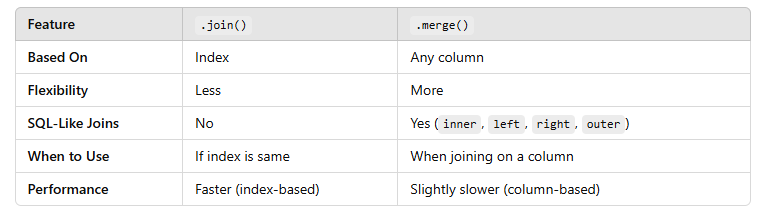

If our DataFrames are indexed properly → ✅ Use .join(), faster.

If we need flexibility (column-based joins) → ✅ Use .merge(), more powerful.

In [17]:
df3=df1.set_index('FellowshipID').join(df2.set_index('FellowshipID'),lsuffix='_left',rsuffix='_right')
df3

,FirstName_left,Skills,FirstName_right,Age
FellowshipID,,,,
1001,Frodo,Hiding,Frodo,50.0
1002,Samwise,Gardening,Samwise,39.0
1003,Gandalf,Spells,NaN,NaN
1004,Pippin,Fireworks,NaN,NaN


So Default its taking left join

In [18]:
df3=df1.set_index('FellowshipID').join(df2.set_index('FellowshipID'),lsuffix='_left',rsuffix='_right',how="inner")
df3

,FirstName_left,Skills,FirstName_right,Age
FellowshipID,,,,
1001,Frodo,Hiding,Frodo,50
1002,Samwise,Gardening,Samwise,39


In [19]:
df3=df1.set_index('FellowshipID').join(df2.set_index('FellowshipID'),lsuffix='_left',rsuffix='_right',how="outer")
df3

,FirstName_left,Skills,FirstName_right,Age
FellowshipID,,,,
1001,Frodo,Hiding,Frodo,50.0
1002,Samwise,Gardening,Samwise,39.0
1003,Gandalf,Spells,NaN,NaN
1004,Pippin,Fireworks,NaN,NaN
1006,NaN,NaN,Legolas,2931.0
1007,NaN,NaN,Elrond,6520.0
1008,NaN,NaN,Barromir,51.0


Concatenating the data frame

Using CONCAT() method

The concat() method in pandas is used to combine multiple DataFrames along rows (axis=0) or columns (axis=1), similar to stacking or merging datasets

Use Case	

Stack data vertically	

Combine dataframes with the same structure

Merge different datasets side-by-side
	
SQL-style joining (matching on keys)

In [20]:
pd.concat([df1,df2])

,FellowshipID,FirstName,Skills,Age
0,1001,Frodo,Hiding,NaN
1,1002,Samwise,Gardening,NaN
2,1003,Gandalf,Spells,NaN
3,1004,Pippin,Fireworks,NaN
0,1001,Frodo,NaN,50.0
1,1002,Samwise,NaN,39.0
2,1006,Legolas,NaN,2931.0
3,1007,Elrond,NaN,6520.0
4,1008,Barromir,NaN,51.0


Specify the Axis also

Use axis=0 for vertical stacking and axis=1 for horizontal merging.

In [21]:
pd.concat([df1,df2],axis=1)

,FellowshipID,FirstName,Skills,FellowshipID,FirstName,Age
0,1001.0,Frodo,Hiding,1001,Frodo,50
1,1002.0,Samwise,Gardening,1002,Samwise,39
2,1003.0,Gandalf,Spells,1006,Legolas,2931
3,1004.0,Pippin,Fireworks,1007,Elrond,6520
4,NaN,NaN,NaN,1008,Barromir,51


We can use join also

In [29]:
pd.concat([df1,df2],join="inner")

,FellowshipID,FirstName
0,1001,Frodo
1,1002,Samwise
2,1003,Gandalf
3,1004,Pippin
0,1001,Frodo
1,1002,Samwise
2,1006,Legolas
3,1007,Elrond
4,1008,Barromir


In [24]:
pd.concat([df1,df2],join="outer")

,FellowshipID,FirstName,Skills,Age
0,1001,Frodo,Hiding,NaN
1,1002,Samwise,Gardening,NaN
2,1003,Gandalf,Spells,NaN
3,1004,Pippin,Fireworks,NaN
0,1001,Frodo,NaN,50.0
1,1002,Samwise,NaN,39.0
2,1006,Legolas,NaN,2931.0
3,1007,Elrond,NaN,6520.0
4,1008,Barromir,NaN,51.0


In [25]:
pd.concat([df1,df2],join="outer",axis=1)

,FellowshipID,FirstName,Skills,FellowshipID,FirstName,Age
0,1001.0,Frodo,Hiding,1001,Frodo,50
1,1002.0,Samwise,Gardening,1002,Samwise,39
2,1003.0,Gandalf,Spells,1006,Legolas,2931
3,1004.0,Pippin,Fireworks,1007,Elrond,6520
4,NaN,NaN,NaN,1008,Barromir,51


Have append method also but not recommended it's deprecated

In [26]:
df1.append(df2)

AttributeError: 'DataFrame' object has no attribute 'append'